In [ ]:
!pip install roboflow
from roboflow import Roboflow
rf = Roboflow(api_key="ojaOdZy3uM9l0ri6psvN")
project = rf.workspace("gerdos-flow").project("badminton-calibration")
version = project.version(4)
dataset = version.download("coco")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 34.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 69.9 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Badminton-calibration-4 in coco:: 100%|██████████| 65/65 [00:00<00:00, 5648.60it/s]


In [ ]:
## drive mount
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.0 MB/s eta 0:00:00


In [ ]:
pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 65.9 MB/s eta 0:00:00


In [ ]:
import json, cv2, os
import numpy as np
from ultralytics import YOLO
from pathlib import Path

# ============================================================
# Load your trained YOLO BB model
# ============================================================
yolo_model = YOLO("/content/drive/MyDrive/bad_court_corner_bounding box/runs/weights/best.pt")

# ============================================================
# Load Roboflow COCO dataset (already downloaded)
# ============================================================
DATASET_PATH = dataset.location


def get_kps_inside_box(all_kps, box, num_kp_per_ann = 4):
    x1, y1, x2, y2 = box
    matched = []

    for i in range(0, len(all_kps), 3):
        kx, ky, kv = all_kps[i], all_kps[i + 1], all_kps[i + 2]

        if kv > 0 and x1 <= kx <= x2 and y1 <= ky <= y2:
            matched.append([kx - x1, ky - y1])

    if len(matched) == num_kp_per_ann:
        return matched

    return None


def order_points(pts):
    pts = sorted(pts, key = lambda x: x[1])

    top = sorted(pts[:2], key = lambda x: x[0])
    bottom = sorted(pts[2:], key = lambda x: x[0])

    ordered = [
        top[0],        # top-left
        top[1],        # top-right
        bottom[1],     # bottom-right
        bottom[0]      # bottom-left
    ]

    return ordered


def build_dataset(split = "train"):
    coco_json = f"{DATASET_PATH}/{split}/_annotations.coco.json"
    images_dir = f"{DATASET_PATH}/{split}"

    out_img_dir = f"regression_dataset/{split}/images"
    out_lbl_dir = f"regression_dataset/{split}/labels"

    os.makedirs(out_img_dir, exist_ok = True)
    os.makedirs(out_lbl_dir, exist_ok = True)

    with open(coco_json) as f:
        coco = json.load(f)

    from collections import defaultdict
    img2anns = defaultdict(list)

    for ann in coco["annotations"]:
        img2anns[ann["image_id"]].append(ann)

    crop_id = 0

    for img_info in coco["images"]:
        img_path = os.path.join(images_dir, img_info["file_name"])

        img = cv2.imread(img_path)
        if img is None:
            continue

        # YOLO detection
        results = yolo_model(img, verbose = False)[0]

        if results.boxes is None:
            continue

        boxes = results.boxes.xyxy.cpu().numpy()
        scores = results.boxes.conf.cpu().numpy()

        all_anns = img2anns[img_info["id"]]

        for box, score in zip(boxes, scores):

            if score < 0.5:
                continue

            x1, y1, x2, y2 = map(int, box)

            matched_kps = None

            for ann in all_anns:
                kps = ann.get("keypoints", [])
                matched_kps = get_kps_inside_box(kps, (x1, y1, x2, y2))

                if matched_kps is not None:
                    break

            if matched_kps is None:
                continue

            crop = img[y1:y2, x1:x2]

            if crop.size == 0:
                continue

            bw = x2 - x1
            bh = y2 - y1

            # ORDER POINTS (VERY IMPORTANT)
            ordered = order_points(matched_kps)

            # NORMALIZE
            label_vals = []

            for (kx, ky) in ordered:
                label_vals.append(kx / bw)
                label_vals.append(ky / bh)

            fname = f"{split}_crop_{crop_id:05d}.jpg"

            cv2.imwrite(f"{out_img_dir}/{fname}", crop)

            lbl_path = f"{out_lbl_dir}/{Path(fname).stem}.txt"

            with open(lbl_path, "w") as f:
              f.write(" ".join([f"{v:.6f}" for v in label_vals]) + "\n")

            crop_id += 1

    print(f"[{split}] Done: {crop_id} crops saved.")


# Run
build_dataset("train")
build_dataset("valid")

print("Dataset ready → regression_dataset/")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
[train] Done: 107 crops saved.
[valid] Done: 29 crops saved.
Dataset ready → regression_dataset/


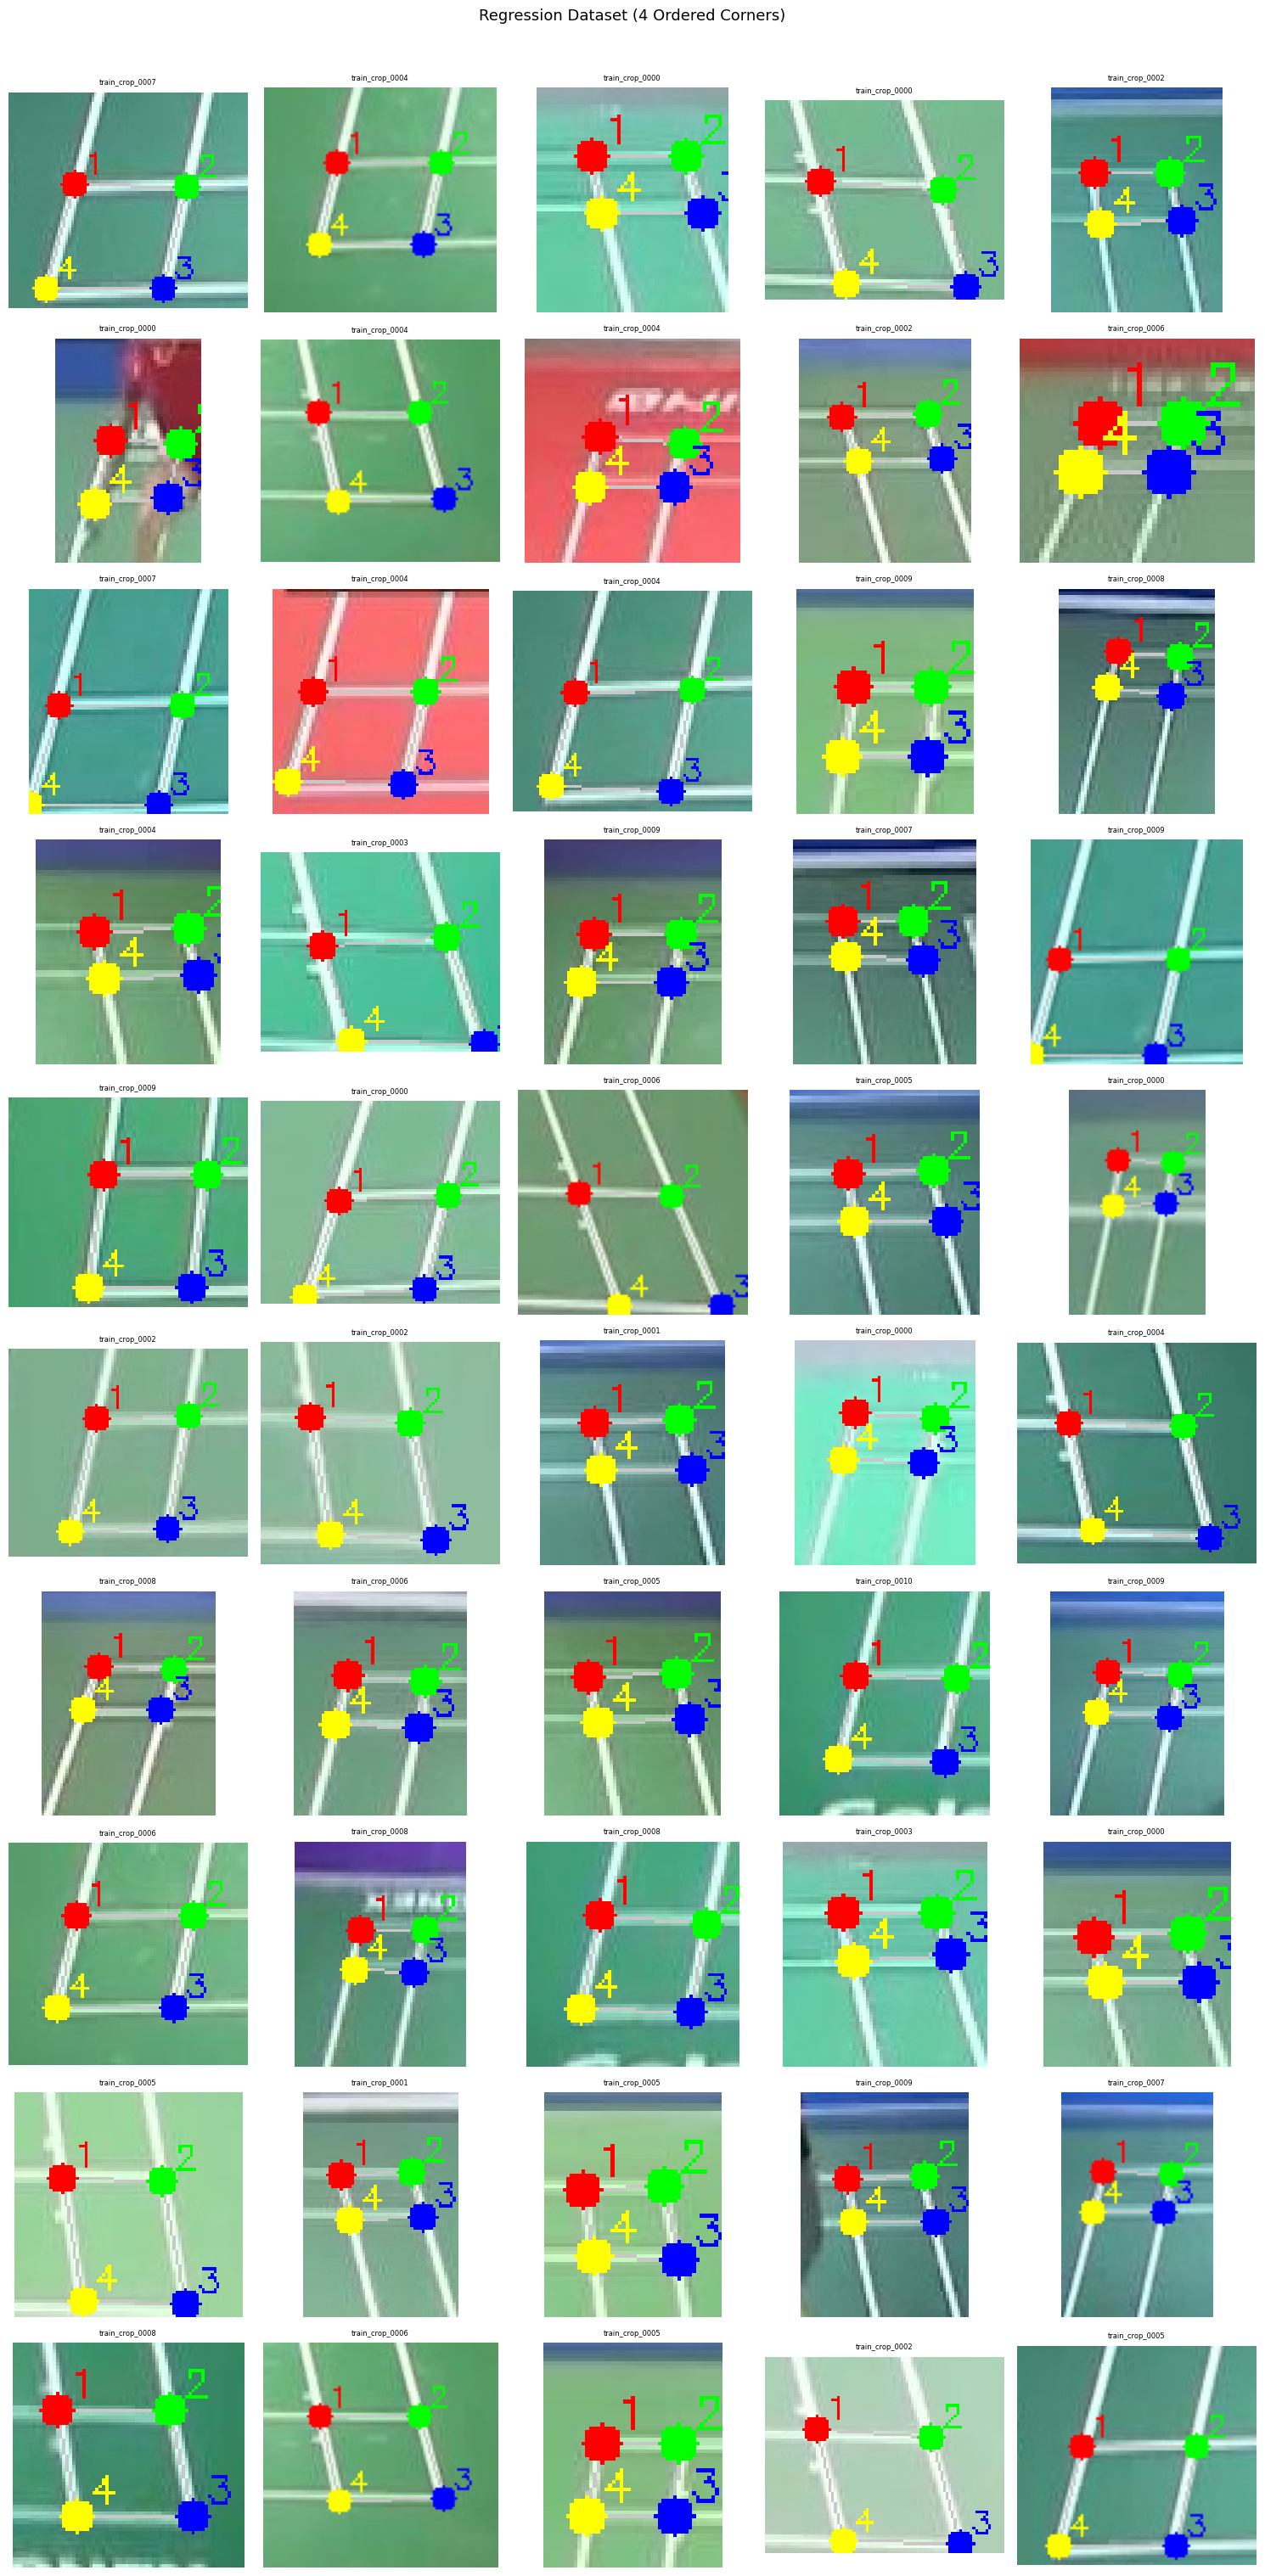

Saved → regression_dataset_samples.png


In [ ]:
import cv2
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def visualize_kp_dataset(images_dir, labels_dir, num_samples = 50, cols = 5):
    img_files = list(Path(images_dir).glob("*.jpg"))

    if len(img_files) == 0:
        print("No images found!")
        return

    samples = random.sample(img_files, min(num_samples, len(img_files)))
    rows = (len(samples) + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize = (cols * 3, rows * 3))
    axes = axes.flatten()

    KP_COLORS = [
        (255, 0, 0),      # top-left
        (0, 255, 0),      # top-right
        (0, 0, 255),      # bottom-right
        (255, 255, 0),    # bottom-left
    ]

    for ax in axes:
        ax.axis("off")

    for idx, img_path in enumerate(samples):

        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        H, W = img.shape[:2]

        lbl_path = Path(labels_dir) / (img_path.stem + ".txt")

        if not lbl_path.exists():
            axes[idx].imshow(img)
            axes[idx].set_title("no label", fontsize = 7, color = "red")
            continue

        with open(lbl_path) as f:
            vals = list(map(float, f.readline().strip().split()))

        if len(vals) != 8:
            axes[idx].imshow(img)
            axes[idx].set_title("bad label", fontsize = 7, color = "red")
            continue

        # Convert normalized → pixel coords
        kps = []
        for i in range(0, 8, 2):
            kx = int(vals[i] * W)
            ky = int(vals[i + 1] * H)
            kps.append((kx, ky))

        draw = img.copy()

        # Draw connections (quad)
        connections = [(0,1), (1,2), (2,3), (3,0)]

        for (a, b) in connections:
            cv2.line(draw,
                     (kps[a][0], kps[a][1]),
                     (kps[b][0], kps[b][1]),
                     (200, 200, 200), 1)

        # Draw keypoints
        for i, (kx, ky) in enumerate(kps):
            color = KP_COLORS[i]

            cv2.circle(draw, (kx, ky), 5, color, -1)

            cv2.putText(draw,
                        str(i + 1),
                        (kx + 4, ky - 4),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.4,
                        color,
                        1)

        axes[idx].imshow(draw)
        axes[idx].set_title(img_path.name[:15], fontsize = 6)

    plt.suptitle("Regression Dataset (4 Ordered Corners)", fontsize = 13, y = 1.01)
    plt.tight_layout()
    plt.savefig("regression_dataset_samples.png", bbox_inches = "tight", dpi = 120)
    plt.show()

    print("Saved → regression_dataset_samples.png")


# ── Run ──────────────────────────────────────────────────────
visualize_kp_dataset(
    images_dir = "regression_dataset/train/images",
    labels_dir = "regression_dataset/train/labels",
    num_samples = 50,
    cols = 5
)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
import cv2
import os
from pathlib import Path
import numpy as np

# ============================================================
# 1. DATASET
# ============================================================
class CourtDataset(Dataset):
    def __init__(self, images_dir, labels_dir):
        self.img_paths = list(Path(images_dir).glob("*.jpg"))
        self.labels_dir = labels_dir

        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((224, 224)),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        img = self.transform(img)

        lbl_path = Path(self.labels_dir) / (img_path.stem + ".txt")

        with open(lbl_path) as f:
            label = list(map(float, f.readline().strip().split()))

        label = torch.tensor(label, dtype=torch.float32)

        return img, label


# ============================================================
# 2. LOAD DATA
# ============================================================
train_dataset = CourtDataset(
    "regression_dataset/train/images",
    "regression_dataset/train/labels"
)

val_dataset = CourtDataset(
    "regression_dataset/valid/images",
    "regression_dataset/valid/labels"
)

train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size = 32, shuffle = False)

print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))


# ============================================================
# 3. MODEL
# ============================================================
class CornerModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = models.resnet18(pretrained = True)

        self.backbone.fc = nn.Sequential(
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, 8),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.backbone(x)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CornerModel().to(device)


# ============================================================
# 4. LOSS + OPTIMIZER
# ============================================================
criterion = nn.SmoothL1Loss()
optimizer = optim.Adam(model.parameters(), lr = 1e-4)


# ============================================================
# 5. TRAIN LOOP
# ============================================================
EPOCHS = 50

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0

    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        preds = model(imgs)

        loss = criterion(preds, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # VALIDATION
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            preds = model(imgs)
            loss = criterion(preds, labels)

            val_loss += loss.item()

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")


# ============================================================
# 6. SAVE MODEL
# ============================================================
torch.save(model.state_dict(), "corner_regression_model.pth")

print("Model saved → corner_regression_model.pth")

The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.


Train samples: 107
Val samples: 29
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 116MB/s]


Epoch 1/50 | Train Loss: 0.1011 | Val Loss: 0.0215
Epoch 2/50 | Train Loss: 0.0528 | Val Loss: 0.0156
Epoch 3/50 | Train Loss: 0.0241 | Val Loss: 0.0092
Epoch 4/50 | Train Loss: 0.0110 | Val Loss: 0.0046
Epoch 5/50 | Train Loss: 0.0054 | Val Loss: 0.0025
Epoch 6/50 | Train Loss: 0.0044 | Val Loss: 0.0014
Epoch 7/50 | Train Loss: 0.0031 | Val Loss: 0.0011
Epoch 8/50 | Train Loss: 0.0026 | Val Loss: 0.0008
Epoch 9/50 | Train Loss: 0.0021 | Val Loss: 0.0007
Epoch 10/50 | Train Loss: 0.0028 | Val Loss: 0.0007
Epoch 11/50 | Train Loss: 0.0013 | Val Loss: 0.0007
Epoch 12/50 | Train Loss: 0.0016 | Val Loss: 0.0006
Epoch 13/50 | Train Loss: 0.0019 | Val Loss: 0.0007
Epoch 14/50 | Train Loss: 0.0015 | Val Loss: 0.0006
Epoch 15/50 | Train Loss: 0.0009 | Val Loss: 0.0005
Epoch 16/50 | Train Loss: 0.0013 | Val Loss: 0.0005
Epoch 17/50 | Train Loss: 0.0015 | Val Loss: 0.0005
Epoch 18/50 | Train Loss: 0.0008 | Val Loss: 0.0005
Epoch 19/50 | Train Loss: 0.0007 | Val Loss: 0.0005
Epoch 20/50 | Train L

Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.


Model loaded ✓


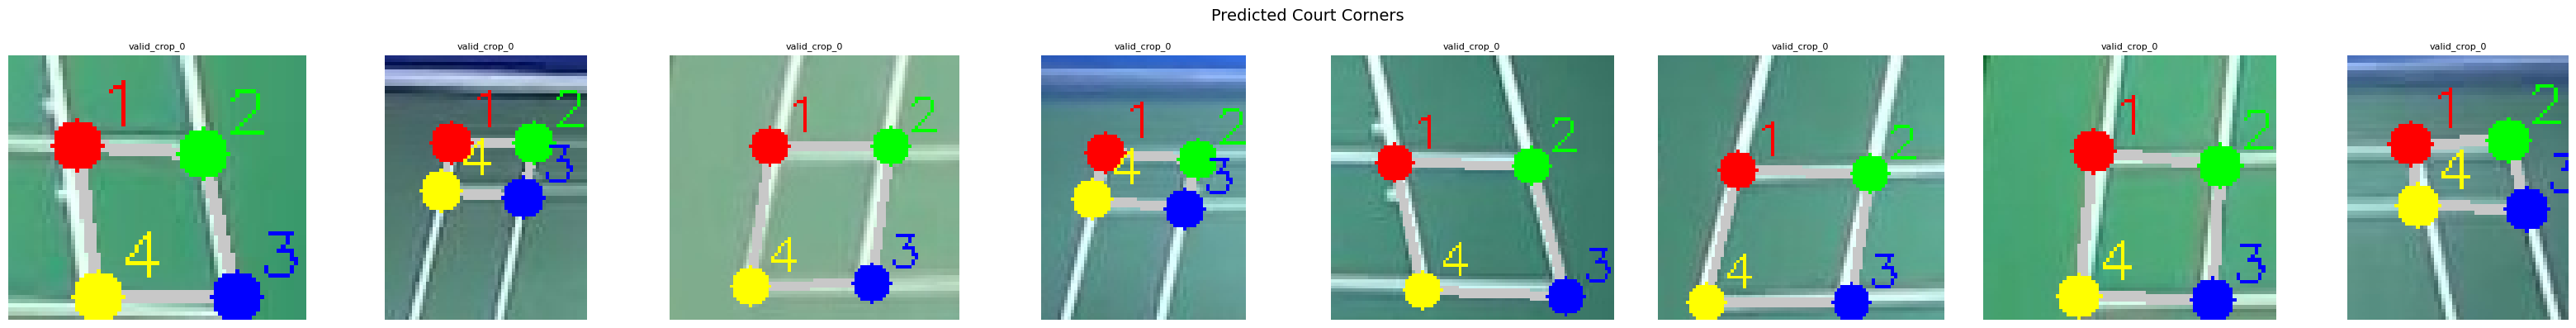

In [ ]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import random
import torchvision.transforms as transforms

# ============================================================
# 1. LOAD MODEL
# ============================================================
class CornerModel(torch.nn.Module):
    def __init__(self):
        super().__init__()

        import torchvision.models as models

        self.backbone = models.resnet18(pretrained = False)

        self.backbone.fc = torch.nn.Sequential(
            torch.nn.Linear(512, 128),
            torch.nn.ReLU(),
            torch.nn.Linear(128, 8),
            torch.nn.Sigmoid()
        )

    def forward(self, x):
        return self.backbone(x)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CornerModel().to(device)
model.load_state_dict(torch.load("corner_regression_model.pth", map_location=device))
model.eval()

print("Model loaded ✓")


# ============================================================
# 2. TRANSFORM
# ============================================================
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])


# ============================================================
# 3. VISUALIZE PREDICTIONS
# ============================================================
def visualize_predictions(images_dir, num_samples = 8):
    img_paths = list(Path(images_dir).glob("*.jpg"))

    samples = random.sample(img_paths, min(num_samples, len(img_paths)))

    fig, axes = plt.subplots(1, len(samples), figsize = (4 * len(samples), 4))

    if len(samples) == 1:
        axes = [axes]

    KP_COLORS = [
        (255, 0, 0),      # top-left
        (0, 255, 0),      # top-right
        (0, 0, 255),      # bottom-right
        (255, 255, 0),    # bottom-left
    ]

    for ax, img_path in zip(axes, samples):

        img = cv2.imread(str(img_path))
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        H, W = img.shape[:2]

        inp = transform(img_rgb).unsqueeze(0).to(device)

        with torch.no_grad():
            pred = model(inp).cpu().numpy()[0]

        # convert normalized → pixel coords
        kps = []
        for i in range(0, 8, 2):
            x = int(pred[i] * W)
            y = int(pred[i+1] * H)
            kps.append((x, y))

        draw = img_rgb.copy()

        # draw quad
        connections = [(0,1), (1,2), (2,3), (3,0)]
        for (a, b) in connections:
            cv2.line(draw,
                     kps[a],
                     kps[b],
                     (200, 200, 200), 2)

        # draw points
        for i, (x, y) in enumerate(kps):
            color = KP_COLORS[i]
            cv2.circle(draw, (x, y), 6, color, -1)
            cv2.putText(draw, str(i+1), (x+5, y-5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)

        ax.imshow(draw)
        ax.set_title(img_path.name[:12], fontsize = 8)
        ax.axis("off")

    plt.suptitle("Predicted Court Corners", fontsize = 14)
    plt.tight_layout()
    plt.show()


# ============================================================
# 4. RUN
# ============================================================
visualize_predictions("regression_dataset/valid/images", num_samples = 8)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
import cv2
from pathlib import Path

# ============================================================
# 1. DATASET
# ============================================================
class CourtDataset(Dataset):
    def __init__(self, images_dir, labels_dir):
        self.img_paths = list(Path(images_dir).glob("*.jpg"))
        self.labels_dir = labels_dir

        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((384, 384)),
            transforms.ColorJitter(brightness=0.3, contrast=0.3),
            transforms.RandomRotation(5),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]

        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        img = self.transform(img)

        lbl_path = Path(self.labels_dir) / (img_path.stem + ".txt")

        with open(lbl_path) as f:
            label = list(map(float, f.readline().strip().split()))

        label = torch.tensor(label, dtype=torch.float32)

        return img, label


train_dataset = CourtDataset(
    "regression_dataset/train/images",
    "regression_dataset/train/labels"
)

val_dataset = CourtDataset(
    "regression_dataset/valid/images",
    "regression_dataset/valid/labels"
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ============================================================
# 2. MODEL FACTORY
# ============================================================
def get_model(name):
    if name == "resnet34":
        model = models.resnet34(pretrained=True)
        in_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Linear(in_features, 128),
            nn.ReLU(),
            nn.Linear(128, 8),
            nn.Sigmoid()
        )

    elif name == "mobilenet":
        model = models.mobilenet_v2(pretrained=True)
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Sequential(
            nn.Linear(in_features, 128),
            nn.ReLU(),
            nn.Linear(128, 8),
            nn.Sigmoid()
        )

    elif name == "efficientnet":
        model = models.efficientnet_b0(pretrained=True)
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Sequential(
            nn.Linear(in_features, 128),
            nn.ReLU(),
            nn.Linear(128, 8),
            nn.Sigmoid()
        )

    return model.to(device)


# ============================================================
# 3. LOSS
# ============================================================
def weighted_loss(pred, target):
    return torch.mean((pred - target) ** 2 * 2.0)


# ============================================================
# 4. TRAIN FUNCTION
# ============================================================
def train_model(model_name):

    print(f"\n🚀 Training: {model_name}")

    model = get_model(model_name)
    optimizer = optim.Adam(model.parameters(), lr=1e-4)

    EPOCHS = 50

    best_val = float("inf")

    for epoch in range(EPOCHS):

        # TRAIN
        model.train()
        train_loss = 0

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            preds = model(imgs)
            loss = weighted_loss(preds, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        # VALIDATION
        model.eval()
        val_loss = 0

        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)

                preds = model(imgs)
                loss = weighted_loss(preds, labels)

                val_loss += loss.item()

        print(f"{model_name} | Epoch {epoch+1} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

        # SAVE BEST
        if val_loss < best_val:
            best_val = val_loss
            torch.save(model.state_dict(), f"{model_name}_best.pth")

    print(f"✅ Best model saved: {model_name}_best.pth")


# ============================================================
# 5. TRAIN ALL MODELS
# ============================================================
for model_name in ["resnet34", "mobilenet", "efficientnet"]:
    train_model(model_name)


🚀 Training: resnet34


Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.


Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 115MB/s]


resnet34 | Epoch 1 | Train: 0.3354 | Val: 0.0840
resnet34 | Epoch 2 | Train: 0.1808 | Val: 0.0509
resnet34 | Epoch 3 | Train: 0.0958 | Val: 0.0265
resnet34 | Epoch 4 | Train: 0.0451 | Val: 0.0121
resnet34 | Epoch 5 | Train: 0.0271 | Val: 0.0060
resnet34 | Epoch 6 | Train: 0.0217 | Val: 0.0043
resnet34 | Epoch 7 | Train: 0.0122 | Val: 0.0038
resnet34 | Epoch 8 | Train: 0.0130 | Val: 0.0032
resnet34 | Epoch 9 | Train: 0.0110 | Val: 0.0032
resnet34 | Epoch 10 | Train: 0.0117 | Val: 0.0028
resnet34 | Epoch 11 | Train: 0.0109 | Val: 0.0025
resnet34 | Epoch 12 | Train: 0.0069 | Val: 0.0022
resnet34 | Epoch 13 | Train: 0.0056 | Val: 0.0019
resnet34 | Epoch 14 | Train: 0.0055 | Val: 0.0016
resnet34 | Epoch 15 | Train: 0.0051 | Val: 0.0016
resnet34 | Epoch 16 | Train: 0.0060 | Val: 0.0014
resnet34 | Epoch 17 | Train: 0.0047 | Val: 0.0013
resnet34 | Epoch 18 | Train: 0.0047 | Val: 0.0015
resnet34 | Epoch 19 | Train: 0.0035 | Val: 0.0012
resnet34 | Epoch 20 | Train: 0.0038 | Val: 0.0011
resnet34 

...

mobilenet | Epoch 1 | Train: 0.3399 | Val: 0.0755
mobilenet | Epoch 2 | Train: 0.1743 | Val: 0.0395
mobilenet | Epoch 3 | Train: 0.0817 | Val: 0.0128
mobilenet | Epoch 4 | Train: 0.0469 | Val: 0.0113
mobilenet | Epoch 5 | Train: 0.0379 | Val: 0.0130
mobilenet | Epoch 6 | Train: 0.0346 | Val: 0.0128
mobilenet | Epoch 7 | Train: 0.0350 | Val: 0.0102
mobilenet | Epoch 8 | Train: 0.0270 | Val: 0.0067
mobilenet | Epoch 9 | Train: 0.0212 | Val: 0.0048
mobilenet | Epoch 10 | Train: 0.0209 | Val: 0.0044
mobilenet | Epoch 11 | Train: 0.0171 | Val: 0.0038
mobilenet | Epoch 12 | Train: 0.0164 | Val: 0.0033
mobilenet | Epoch 13 | Train: 0.0171 | Val: 0.0034
mobilenet | Epoch 14 | Train: 0.0133 | Val: 0.0026
mobilenet | Epoch 15 | Train: 0.0128 | Val: 0.0026
mobilenet | Epoch 16 | Train: 0.0123 | Val: 0.0022
mobilenet | Epoch 17 | Train: 0.0136 | Val: 0.0025
mobilenet | Epoch 18 | Train: 0.0102 | Val: 0.0023
mobilenet | Epoch 19 | Train: 0.0102 | Val: 0.0027
mobilenet | Epoch 20 | Train: 0.0097 | V

Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.


mobilenet | Epoch 50 | Train: 0.0061 | Val: 0.0016
✅ Best model saved: mobilenet_best.pth

🚀 Training: efficientnet
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 194MB/s]


efficientnet | Epoch 1 | Train: 0.4304 | Val: 0.1163
efficientnet | Epoch 2 | Train: 0.3565 | Val: 0.1105
efficientnet | Epoch 3 | Train: 0.3080 | Val: 0.0983
efficientnet | Epoch 4 | Train: 0.2242 | Val: 0.0788
efficientnet | Epoch 5 | Train: 0.1474 | Val: 0.0488
efficientnet | Epoch 6 | Train: 0.1079 | Val: 0.0256
efficientnet | Epoch 7 | Train: 0.0836 | Val: 0.0141
efficientnet | Epoch 8 | Train: 0.0583 | Val: 0.0157
efficientnet | Epoch 9 | Train: 0.0507 | Val: 0.0169
efficientnet | Epoch 10 | Train: 0.0494 | Val: 0.0150
efficientnet | Epoch 11 | Train: 0.0448 | Val: 0.0110
efficientnet | Epoch 12 | Train: 0.0443 | Val: 0.0076
efficientnet | Epoch 13 | Train: 0.0372 | Val: 0.0052
efficientnet | Epoch 14 | Train: 0.0350 | Val: 0.0057
efficientnet | Epoch 15 | Train: 0.0301 | Val: 0.0047
efficientnet | Epoch 16 | Train: 0.0267 | Val: 0.0047
efficientnet | Epoch 17 | Train: 0.0267 | Val: 0.0045
efficientnet | Epoch 18 | Train: 0.0266 | Val: 0.0043
efficientnet | Epoch 19 | Train: 0.02

In [ ]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import random
import torchvision.transforms as transforms
import torchvision.models as models

# ============================================================
# 1. LOAD MODEL (MATCH TRAINING → RESNET18)
# ============================================================
class CornerModel(torch.nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = models.resnet18(pretrained = False)

        self.backbone.fc = torch.nn.Sequential(
            torch.nn.Linear(512, 128),
            torch.nn.ReLU(),
            torch.nn.Linear(128, 8),
            torch.nn.Sigmoid()
        )

    def forward(self, x):
        return self.backbone(x)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CornerModel().to(device)

model.load_state_dict(
    torch.load("/content/corner_regression_model.pth", map_location = device)
)

model.eval()

print("Model loaded ✓")


# ============================================================
# 2. TRANSFORM (MATCH TRAINING SIZE)
# ============================================================
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((384, 384)),
    transforms.ToTensor()
])


# ============================================================
# 3. VISUALIZATION FUNCTION
# ============================================================
def visualize_test(images_dir, num_samples = 8):

    img_paths = list(Path(images_dir).glob("*.jpg"))

    if len(img_paths) == 0:
        print("No images found!")
        return

    samples = random.sample(img_paths, min(num_samples, len(img_paths)))

    fig, axes = plt.subplots(1, len(samples), figsize = (4 * len(samples), 4))

    if len(samples) == 1:
        axes = [axes]

    KP_COLORS = [
        (255, 0, 0),      # top-left
        (0, 255, 0),      # top-right
        (0, 0, 255),      # bottom-right
        (255, 255, 0),    # bottom-left
    ]

    for ax, img_path in zip(axes, samples):

        img = cv2.imread(str(img_path))

        if img is None:
            ax.set_title("bad image")
            ax.axis("off")
            continue

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        H, W = img.shape[:2]

        inp = transform(img_rgb).unsqueeze(0).to(device)

        with torch.no_grad():
            pred = model(inp).cpu().numpy()[0]

        # Convert normalized → pixel coords
        kps = []
        for i in range(0, 8, 2):
            x = int(pred[i] * W)
            y = int(pred[i + 1] * H)
            kps.append((x, y))

        draw = img_rgb.copy()

        # Draw quadrilateral
        connections = [(0,1), (1,2), (2,3), (3,0)]

        for (a, b) in connections:
            cv2.line(draw, kps[a], kps[b], (200, 200, 200), 2)

        # Draw points
        for i, (x, y) in enumerate(kps):
            cv2.circle(draw, (x, y), 6, KP_COLORS[i], -1)

            cv2.putText(draw,
                        str(i + 1),
                        (x + 5, y - 5),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.5,
                        KP_COLORS[i],
                        1)

        ax.imshow(draw)
        ax.set_title(img_path.name[:12], fontsize = 8)
        ax.axis("off")

    plt.suptitle("Corner Predictions (ResNet18)", fontsize = 14)
    plt.tight_layout()
    plt.show()


# ============================================================
# 4. RUN
# ============================================================
visualize_test("regression_dataset/valid/images", num_samples = 8)

RuntimeError: Error(s) in loading state_dict for CornerModel:
	Missing key(s) in state_dict: "backbone.conv1.weight", "backbone.bn1.weight", "backbone.bn1.bias", "backbone.bn1.running_mean", "backbone.bn1.running_var", "backbone.layer1.0.conv1.weight", "backbone.layer1.0.bn1.weight", "backbone.layer1.0.bn1.bias", "backbone.layer1.0.bn1.running_mean", "backbone.layer1.0.bn1.running_var", "backbone.layer1.0.conv2.weight", "backbone.layer1.0.bn2.weight", "backbone.layer1.0.bn2.bias", "backbone.layer1.0.bn2.running_mean", "backbone.layer1.0.bn2.running_var", "backbone.layer1.1.conv1.weight", "backbone.layer1.1.bn1.weight", "backbone.layer1.1.bn1.bias", "backbone.layer1.1.bn1.running_mean", "backbone.layer1.1.bn1.running_var", "backbone.layer1.1.conv2.weight", "backbone.layer1.1.bn2.weight", "backbone.layer1.1.bn2.bias", "backbone.layer1.1.bn2.running_mean", "backbone.layer1.1.bn2.running_var", "backbone.layer2.0.conv1.weight", "backbone.layer2.0.bn1.weight", "backbone.layer2.0.bn1.bias", "

All models loaded correctly ✓


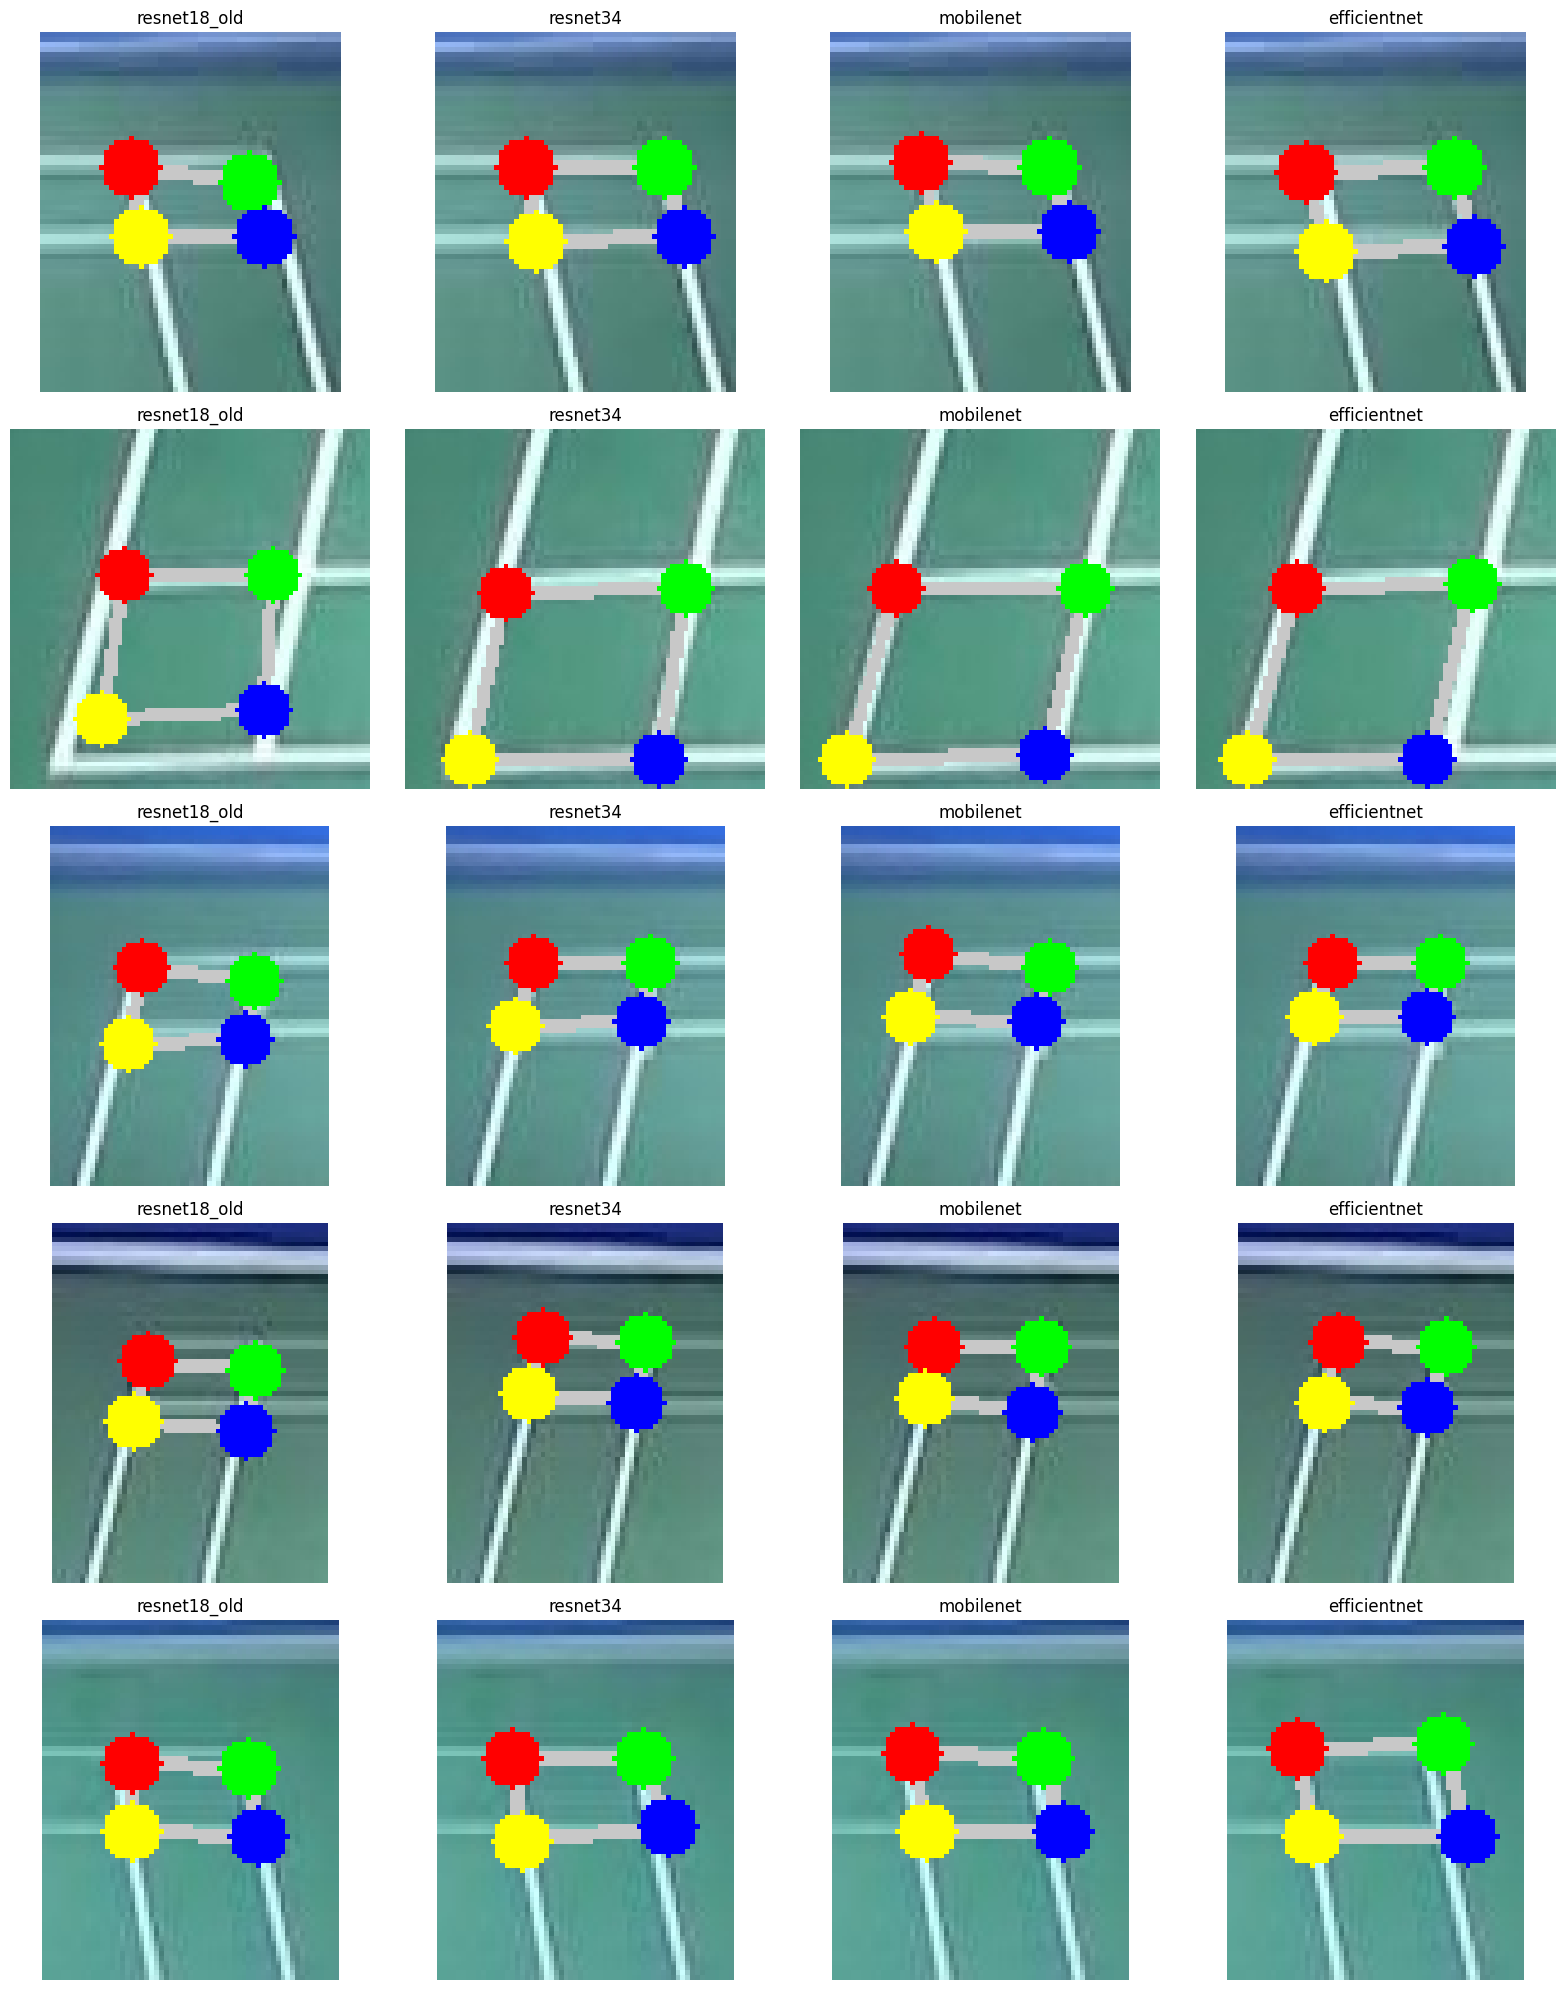

In [ ]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import random
import torchvision.transforms as transforms
import torchvision.models as models

# ============================================================
# DEVICE
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ============================================================
# MODEL DEFINITIONS
# ============================================================
class ResNet18Model(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = models.resnet18(pretrained=False)
        self.backbone.fc = torch.nn.Sequential(
            torch.nn.Linear(512,128),
            torch.nn.ReLU(),
            torch.nn.Linear(128,8),
            torch.nn.Sigmoid()
        )
    def forward(self,x): return self.backbone(x)


class ResNet34Model(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = models.resnet34(pretrained=False)
        self.backbone.fc = torch.nn.Sequential(
            torch.nn.Linear(512,128),
            torch.nn.ReLU(),
            torch.nn.Linear(128,8),
            torch.nn.Sigmoid()
        )
    def forward(self,x): return self.backbone(x)


class MobileNetModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = models.mobilenet_v2(pretrained=False)
        self.backbone.classifier[1] = torch.nn.Sequential(
            torch.nn.Linear(self.backbone.last_channel,128),
            torch.nn.ReLU(),
            torch.nn.Linear(128,8),
            torch.nn.Sigmoid()
        )
    def forward(self,x): return self.backbone(x)


class EfficientNetModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = models.efficientnet_b0(pretrained=False)
        self.backbone.classifier[1] = torch.nn.Sequential(
            torch.nn.Linear(self.backbone.classifier[1].in_features,128),
            torch.nn.ReLU(),
            torch.nn.Linear(128,8),
            torch.nn.Sigmoid()
        )
    def forward(self,x): return self.backbone(x)


# ============================================================
# ============================================================
# LOAD MODELS (HANDLE BOTH TYPES)
# ============================================================
models_dict = {}

# ---------------- RESNET18 (OLD CUSTOM MODEL) ----------------
class OldResNet18(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = models.resnet18(weights=None)
        self.backbone.fc = torch.nn.Sequential(
            torch.nn.Linear(512,128),
            torch.nn.ReLU(),
            torch.nn.Linear(128,8),
            torch.nn.Sigmoid()
        )
    def forward(self,x): return self.backbone(x)

m = OldResNet18().to(device)
m.load_state_dict(torch.load("corner_regression_model.pth", map_location=device))
m.eval()
models_dict["resnet18_old"] = m


# ---------------- RESNET34 (NEW) ----------------
m = models.resnet34(weights=None)
m.fc = torch.nn.Sequential(
    torch.nn.Linear(m.fc.in_features,128),
    torch.nn.ReLU(),
    torch.nn.Linear(128,8),
    torch.nn.Sigmoid()
)
m.load_state_dict(torch.load("resnet34_best.pth", map_location=device))
m.to(device).eval()
models_dict["resnet34"] = m


# ---------------- MOBILENET ----------------
m = models.mobilenet_v2(weights=None)
m.classifier[1] = torch.nn.Sequential(
    torch.nn.Linear(m.last_channel,128),
    torch.nn.ReLU(),
    torch.nn.Linear(128,8),
    torch.nn.Sigmoid()
)
m.load_state_dict(torch.load("mobilenet_best.pth", map_location=device))
m.to(device).eval()
models_dict["mobilenet"] = m


# ---------------- EFFICIENTNET ----------------
m = models.efficientnet_b0(weights=None)
m.classifier[1] = torch.nn.Sequential(
    torch.nn.Linear(m.classifier[1].in_features,128),
    torch.nn.ReLU(),
    torch.nn.Linear(128,8),
    torch.nn.Sigmoid()
)
m.load_state_dict(torch.load("efficientnet_best.pth", map_location=device))
m.to(device).eval()
models_dict["efficientnet"] = m


print("All models loaded correctly ✓")


# ============================================================
# TRANSFORM
# ============================================================
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((384,384)),
    transforms.ToTensor()
])


# ============================================================
# VISUALIZATION
# ============================================================
def compare_models(images_dir, num_samples=5):

    img_paths = list(Path(images_dir).glob("*.jpg"))
    samples = random.sample(img_paths, min(num_samples, len(img_paths)))

    model_names = list(models_dict.keys())

    rows = len(samples)
    cols = len(model_names)

    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))

    if rows == 1:
        axes = [axes]

    KP_COLORS = [(255,0,0),(0,255,0),(0,0,255),(255,255,0)]

    for r, img_path in enumerate(samples):

        img = cv2.imread(str(img_path))
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        H, W = img.shape[:2]

        inp = transform(img_rgb).unsqueeze(0).to(device)

        for c, name in enumerate(model_names):

            model = models_dict[name]

            with torch.no_grad():
                pred = model(inp).cpu().numpy()[0]

            kps = []
            for i in range(0,8,2):
                x = int(pred[i]*W)
                y = int(pred[i+1]*H)
                kps.append((x,y))

            draw = img_rgb.copy()

            # quad
            for a,b in [(0,1),(1,2),(2,3),(3,0)]:
                cv2.line(draw, kps[a], kps[b], (200,200,200), 2)

            # points
            for i,(x,y) in enumerate(kps):
                cv2.circle(draw, (x,y), 6, KP_COLORS[i], -1)

            axes[r][c].imshow(draw)
            axes[r][c].set_title(name)
            axes[r][c].axis("off")

    plt.tight_layout()
    plt.show()


# ============================================================
# RUN
# ============================================================
compare_models("regression_dataset/valid/images", num_samples=5)

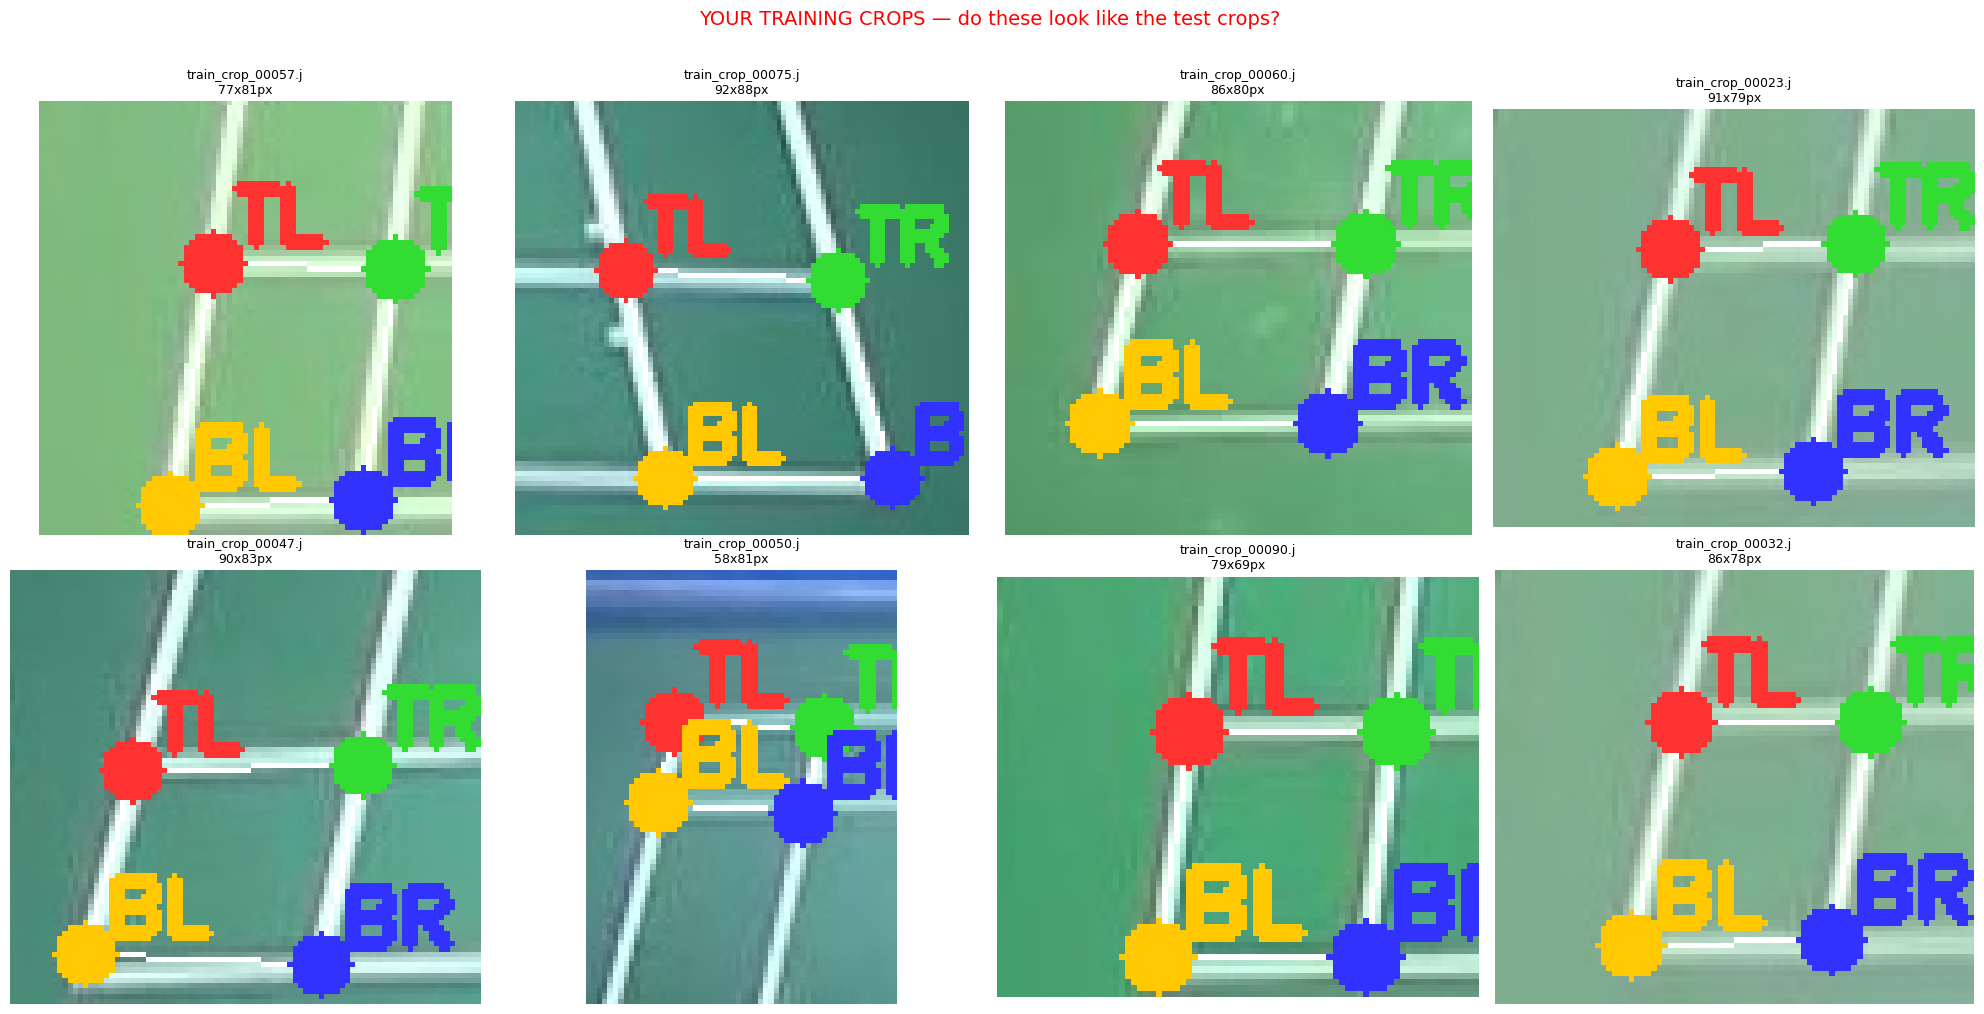

In [ ]:

import os
import random
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

# Show 8 random crops from your training set
train_img_dir = "regression_dataset/train/images"
train_lbl_dir = "regression_dataset/train/labels"

img_files = list(Path(train_img_dir).glob("*.jpg"))
samples   = random.sample(img_files, min(8, len(img_files)))

KP_COLORS = [(255,50,50),(50,220,50),(50,50,255),(255,200,0)]
KP_NAMES  = ["TL","TR","BR","BL"]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, img_path in enumerate(samples):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    H, W = img.shape[:2]

    lbl_path = Path(train_lbl_dir) / (img_path.stem + ".txt")
    with open(lbl_path) as f:
        vals = list(map(float, f.readline().strip().split()))

    draw = img.copy()
    kps  = []
    for k in range(0, 8, 2):
        px = int(vals[k]   * W)
        py = int(vals[k+1] * H)
        kps.append((px, py))

    for a, b in [(0,1),(1,2),(2,3),(3,0)]:
        cv2.line(draw, kps[a], kps[b], (255,255,255), 1)
    for j, (px, py) in enumerate(kps):
        cv2.circle(draw, (px, py), 6, KP_COLORS[j], -1)
        cv2.putText(draw, KP_NAMES[j], (px+4, py-4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, KP_COLORS[j], 2)

    axes[idx].imshow(draw)
    axes[idx].set_title(f"{img_path.name[:18]}\n{W}x{H}px", fontsize=9)
    axes[idx].axis("off")

plt.suptitle("YOUR TRAINING CROPS — do these look like the test crops?",
             fontsize=14, color="red", y=1.01)
plt.tight_layout()
plt.show()